C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data...
Building Preprocessing Pipeline...
Training XGBoost Model...

=== XGBoost Model Performance ===
Validation ROC-AUC Score: 0.8933

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.90     14246
           1       0.31      0.77      0.45      1346

    accuracy                           0.84     15592
   macro avg       0.65      0.81      0.68     15592
weighted avg       0.92      0.84      0.86     15592

Generating SHAP Explanations...


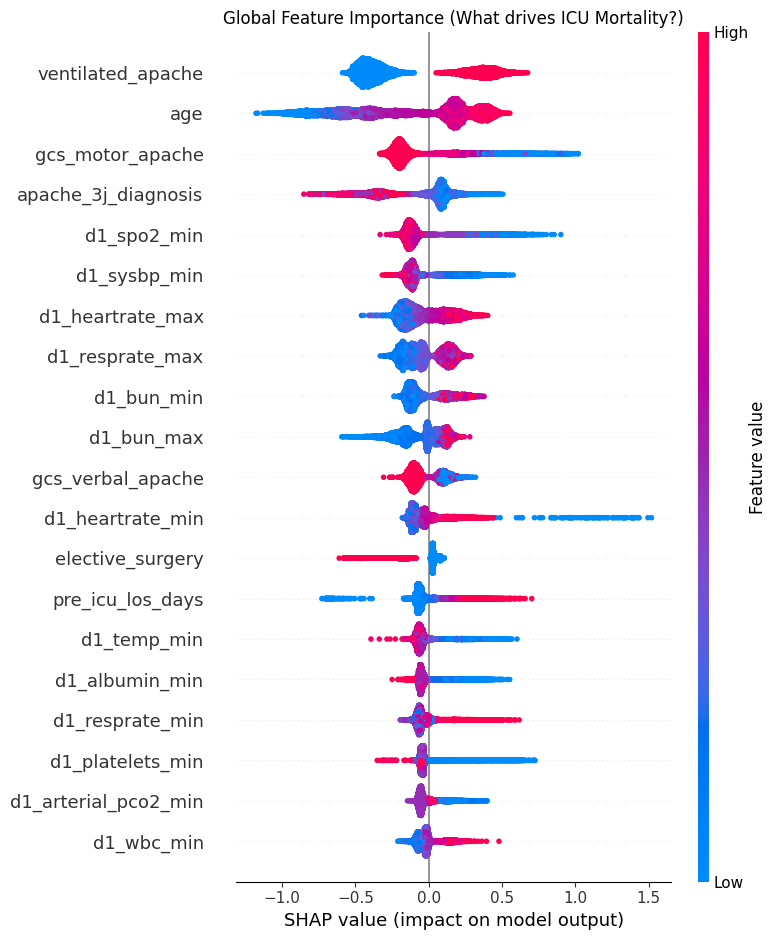


Explaining prediction for Patient Index 1 (Predicted High-Risk)


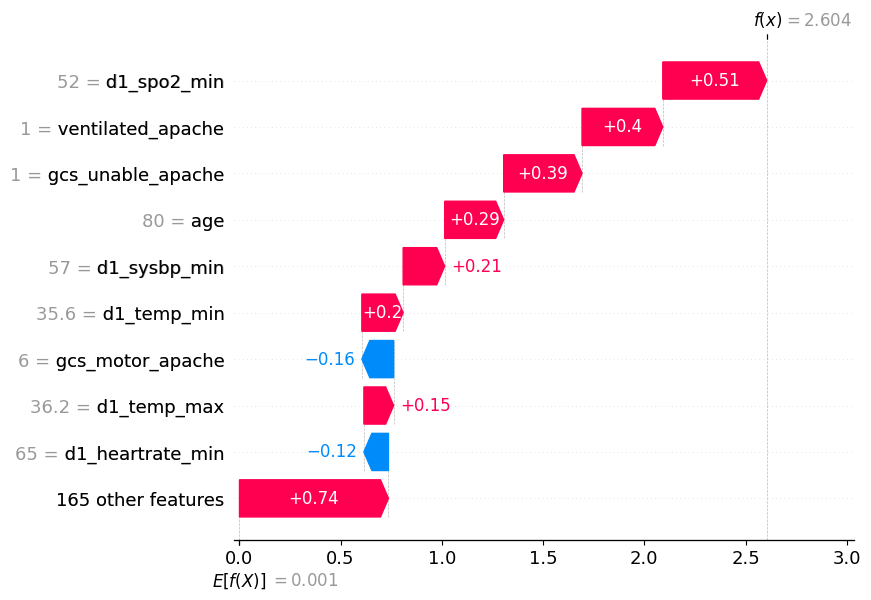

In [1]:
# ==========================================
# ICU Mortality Prediction Engine
# ==========================================

import pandas as pd
import numpy as np
import shap
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

# --- 1. DATA LOADING & CLEANING ---
print("Loading data...")
df = pd.read_csv('icu_train.csv')

# Drop Target-leaking columns and IDs
cols_to_drop = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id', 
                'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore', inplace=True)

# Drop columns with more than 65% missing values
missing_ratio = df.isnull().mean()
heavy_nan_cols = missing_ratio[missing_ratio > 0.65].index
df.drop(columns=heavy_nan_cols, inplace=True)

# Separate Features and Target
X = df.drop(columns=['hospital_death'])
y = df['hospital_death']

# --- 2. TRAIN/VAL SPLIT (Prevents Data Leakage) ---
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. ROBUST PREPROCESSING PIPELINE ---
print("Building Preprocessing Pipeline...")
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Numeric: Fill missing with Median
numeric_transformer = SimpleImputer(strategy='median')

# Categorical: Fill missing with Mode -> One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Fit ONLY on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# Reconstruct DataFrames with valid feature names (Required for SHAP)
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
feature_names = list(numerical_cols) + list(cat_feature_names)

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_val_df = pd.DataFrame(X_val_processed, columns=feature_names)

# --- 4. MODELING (XGBoost) ---
print("Training XGBoost Model...")
# Calculate scale_pos_weight for imbalanced classes
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_weight, # Handles the 92% vs 8% imbalance
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

xgb_model.fit(X_train_df, y_train)

# Saving artifacts for production
joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(xgb_model, 'xgb_model.joblib')

# --- 5. EVALUATION ---
# predict_proba returns [prob_class_0, prob_class_1]. We only need class 1 ([:, 1])
y_pred_proba = xgb_model.predict_proba(X_val_df)[:, 1] 
y_pred = xgb_model.predict(X_val_df)

roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"\n=== XGBoost Model Performance ===")
print(f"Validation ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# --- 6. EXPLAINABLE AI (SHAP) ---
print("Generating SHAP Explanations...")
shap.initjs()
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_val_df)

# Plot 1: Global Feature Importance
plt.figure()
plt.title("Global Feature Importance (What drives ICU Mortality?)")
shap.summary_plot(shap_values, X_val_df, show=False)
plt.show()

# Plot 2: Local Explanation for a High-Risk Patient
high_risk_indices = np.where(y_pred == 1)[0]
if len(high_risk_indices) > 0:
    patient_idx = high_risk_indices[0] # Take the first predicted death
    print(f"\nExplaining prediction for Patient Index {patient_idx} (Predicted High-Risk)")
    shap.plots.waterfall(shap_values[patient_idx])
else:
    print("No high-risk patients predicted.")